# 🧠 Mindspace — Mental Health Classification: Exploratory Data Analysis

> **Goal:** Understand which linguistic, emotional, and semantic features distinguish six mental health conditions — *Anxiety, Bipolar Mania, Depression, Phobia, Stress,* and *Suicidal Tendency* — and identify the features most predictive of a patient's condition.

---

| Item | Detail |
|---|---|
| **Dataset** | `balanced-dataset.csv` — Mental Health Synthetic Dataset (balanced) |
| **Columns** | 66 features + 1 target |
| **Target** | `target` — 6 mental health classes |
| **Classes** | Anxiety · Bipolar Mania · Depression · Phobia · Stress · Suicidal Tendency |
| **Feature groups** | 26 Linguistic · 5 Topic · 32 Embedding |

> ℹ️ **Row count** is printed dynamically in the next cell after loading the CSV.

---

### Table of Contents
1. Setup & Data Loading
2. Dataset Overview
3. Class Distribution & Imbalance
4. Per-Class Feature Statistics
5. Key Feature KDE Distributions
6. Box Plots by Class
7. Correlation Matrix
8. Kruskal-Wallis Statistical Tests
9. Random Forest Feature Importance
10. PCA on Embedding Features
11. Topic Feature Analysis
12. Language Distribution
13. Pairplot — Top 4 Features
14. Summary & Conclusions


In [14]:
# ── Setup ──────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from IPython.display import display, HTML

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Paths
BASE    = os.path.abspath(".")
CHARTS  = os.path.join(BASE, "output", "charts")
STATS   = os.path.join(BASE, "output", "stats")

# Load dataset — eda/balanced-dataset.csv
src = os.path.join(BASE, "balanced-dataset.csv")
if not os.path.exists(src):
    raise FileNotFoundError(
        f"❌ Could not find: {src}\n"
        "Please make sure 'balanced-dataset.csv' is in the eda/ folder."
    )

df = pd.read_csv(src)

# Column groups
LING_COLS = [
    "total_word_count", "unique_word_count", "ttr",
    "positive_emotion_ratio", "negative_emotion_ratio",
    "fear_word_frequency", "sadness_word_frequency", "anger_word_frequency",
    "uncertainty_word_frequency", "filler_word_frequency", "repetition_rate",
    "rumination_phrase_frequency", "semantic_coherence_score",
    "language_model_perplexity", "overall_sentiment_score",
    "past_focus_ratio", "present_focus_ratio", "future_focus_ratio",
    "noun_ratio", "verb_ratio", "adjective_ratio", "adverb_ratio",
    "avg_sentence_length", "parse_tree_depth",
    "topic_shift_frequency", "self_reference_density",
]
TOPIC_COLS = [c for c in df.columns if c.startswith("topic_")]
EMB_COLS   = [c for c in df.columns if c.startswith("emb_")]
TARGET     = "target"
CLASSES    = sorted(df[TARGET].unique())
PALETTE    = dict(zip(CLASSES, sns.color_palette("Set2", len(CLASSES))))

# ── Dataset summary ────────────────────────────────────────────────────────
print("=" * 52)
print("  📂 Dataset Loaded")
print("=" * 52)
print(f"  {'File':<22} {os.path.basename(src)}")
print(f"  {'Path':<22} {src}")
print(f"  {'Rows':<22} {df.shape[0]:,} patient samples")
print(f"  {'Columns':<22} {df.shape[1]}")
print(f"  {'Classes':<22} {len(CLASSES)} — {', '.join(CLASSES)}")
print(f"  {'Linguistic features':<22} {len(LING_COLS)}")
print(f"  {'Topic features':<22} {len(TOPIC_COLS)}")
print(f"  {'Embedding features':<22} {len(EMB_COLS)}")
print("=" * 52)


  📂 Dataset Loaded
  File                   balanced-dataset.csv
  Path                   c:\Users\vicky\OneDrive\Desktop\SCS-projects\Mindspace-voice-agent\eda\balanced-dataset.csv
  Rows                   58,956 patient samples
  Columns                66
  Classes                6 — Anxiety, Bipolar_Mania, Depression, Phobia, Stress, Suicidal_Tendency
  Linguistic features    26
  Topic features         6
  Embedding features     32


---
## 2. Dataset Overview

A quick look at the shape, data types, missing values, and numeric statistics for every feature.


In [15]:
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Missing values report
info = pd.DataFrame({
    "dtype":  df.dtypes,
    "nulls":  df.isnull().sum(),
    "null_%": (df.isnull().mean() * 100).round(2),
    "unique": df.nunique(),
})
null_report = info[info["nulls"] > 0]
if null_report.empty:
    print("✅ No missing values found in any column.")
else:
    print("⚠️  Columns with missing values:")
    display(null_report)

# Numeric summary
print("\n📊 Numeric feature summary (linguistic + topic):")
summary = df[LING_COLS + TOPIC_COLS].describe().T.round(3)
display(summary.style
        .background_gradient(cmap="Blues", subset=pd.IndexSlice[:, ["mean", "std"]])
        .format(lambda v: f"{v:.3f}"))


Shape : 58,956 rows × 66 columns

✅ No missing values found in any column.

📊 Numeric feature summary (linguistic + topic):


KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

---
## 3. Class Distribution & Imbalance

How many samples belong to each mental health class? Is the dataset balanced?


Class                     Count  % of total
────────────────────────────────────────────
Anxiety                    9826       16.7%  ████████
Suicidal_Tendency          9826       16.7%  ████████
Phobia                     9826       16.7%  ████████
Depression                 9826       16.7%  ████████
Bipolar_Mania              9826       16.7%  ████████
Stress                     9826       16.7%  ████████
────────────────────────────────────────────
Total                     58956

⚖️  Imbalance ratio (max/min): 1.00x


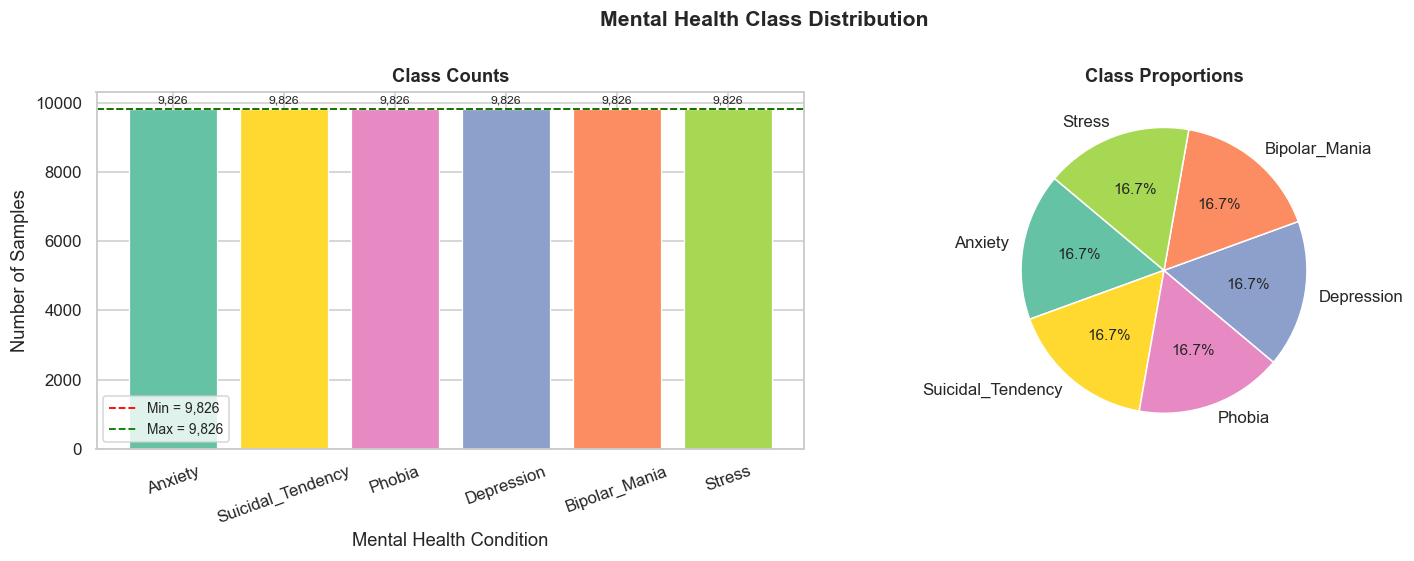

In [16]:
counts      = df[TARGET].value_counts().sort_values(ascending=False)
proportions = (counts / counts.sum() * 100).round(2)
imbalance   = counts.max() / counts.min()

print(f"{'Class':<22} {'Count':>8}  {'% of total':>10}")
print("─" * 44)
for cls, cnt in counts.items():
    bar = "█" * int(proportions[cls] / 2)
    print(f"{cls:<22} {cnt:>8}  {proportions[cls]:>9.1f}%  {bar}")
print("─" * 44)
print(f"{'Total':<22} {counts.sum():>8}")
print(f"\n⚖️  Imbalance ratio (max/min): {imbalance:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[c] for c in counts.index]

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Counts", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mental Health Condition")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=20)
axes[0].axhline(counts.min(), color="red", linestyle="--", linewidth=1.2, label=f"Min = {counts.min():,}")
axes[0].axhline(counts.max(), color="green", linestyle="--", linewidth=1.2, label=f"Max = {counts.max():,}")
axes[0].legend(fontsize=9)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 150, f"{v:,}", ha="center", fontsize=8)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1})
axes[1].set_title("Class Proportions", fontsize=12, fontweight="bold")

plt.suptitle("Mental Health Class Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 4. Per-Class Feature Statistics

**Z-scored median heatmap** — each cell shows how far above/below the overall median a class sits for each feature.  
🔴 = high relative value · 🟢 = low relative value


📊 Mean feature values per class:


,Anxiety,Bipolar_Mania,Depression,Phobia,Stress,Suicidal_Tendency
Feature,,,,,,
total_word_count,304.452,551.719,308.286,303.102,304.090,304.868
unique_word_count,152.640,276.279,155.176,151.705,153.034,152.725
ttr,0.502,0.501,0.504,0.501,0.504,0.501
positive_emotion_ratio,0.041,0.041,0.021,0.041,0.041,0.012
negative_emotion_ratio,0.053,0.053,0.091,0.053,0.053,0.132
fear_word_frequency,0.064,0.026,0.026,0.090,0.025,0.026
sadness_word_frequency,0.033,0.033,0.066,0.033,0.033,0.115
anger_word_frequency,0.026,0.026,0.026,0.026,0.064,0.026
uncertainty_word_frequency,0.082,0.033,0.033,0.065,0.033,0.033


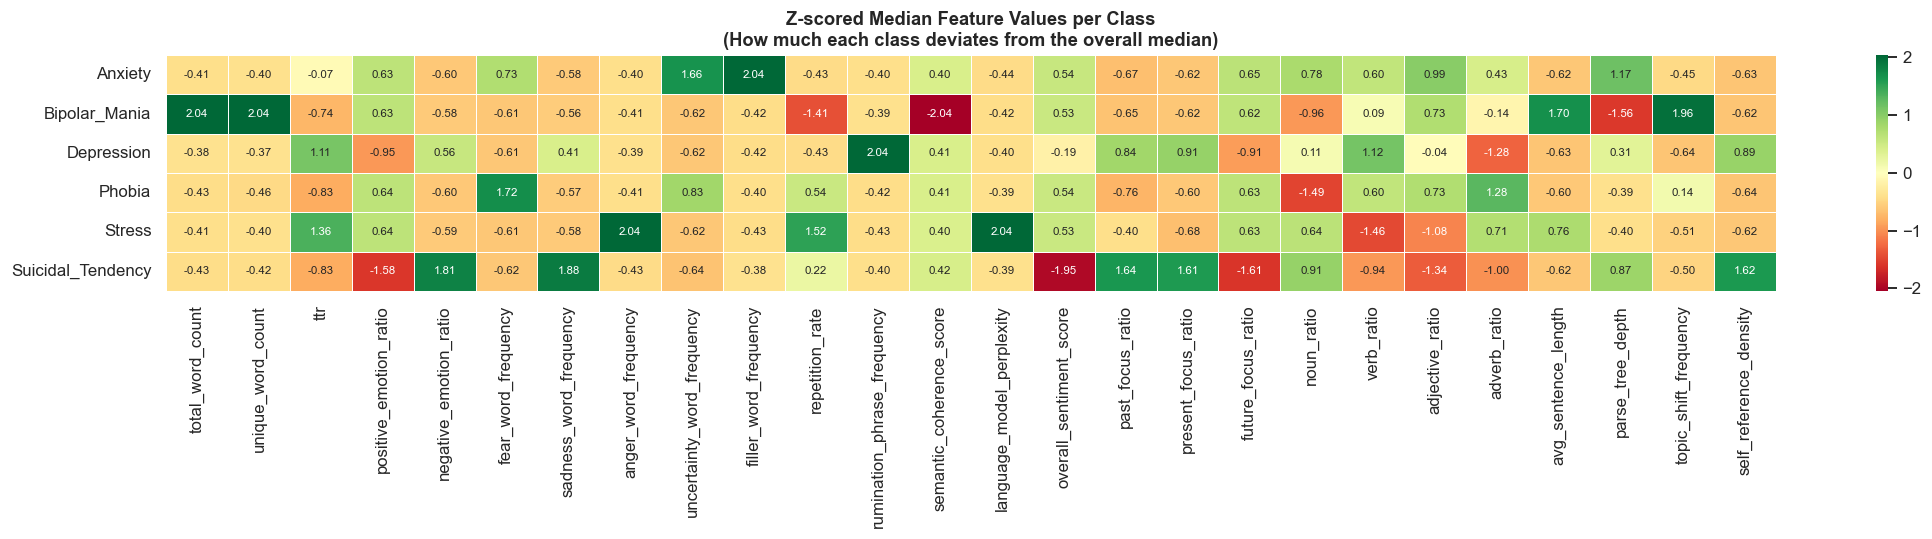

In [17]:
means   = df.groupby(TARGET)[LING_COLS].mean().round(4)
medians = df.groupby(TARGET)[LING_COLS].median().round(4)

print("📊 Mean feature values per class:")
# Reset index before styling to avoid non-unique index Styler error
means_display = means.T.reset_index()
means_display.columns.name = None
means_display = means_display.rename(columns={"index": "Feature"}).set_index("Feature")
display(means_display.style
        .background_gradient(cmap="RdYlGn", axis=1)
        .format("{:.3f}"))

medians_z = (medians - medians.mean()) / (medians.std() + 1e-9)

fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(medians_z, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.4, annot_kws={"size": 7.5}, ax=ax)
ax.set_title("Z-scored Median Feature Values per Class\n(How much each class deviates from the overall median)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


---
## 5. Key Feature Distributions by Class (KDE)

Kernel Density Estimate plots show the **shape of each feature's distribution** per class.  
Non-overlapping peaks = strong discriminative power for that feature.


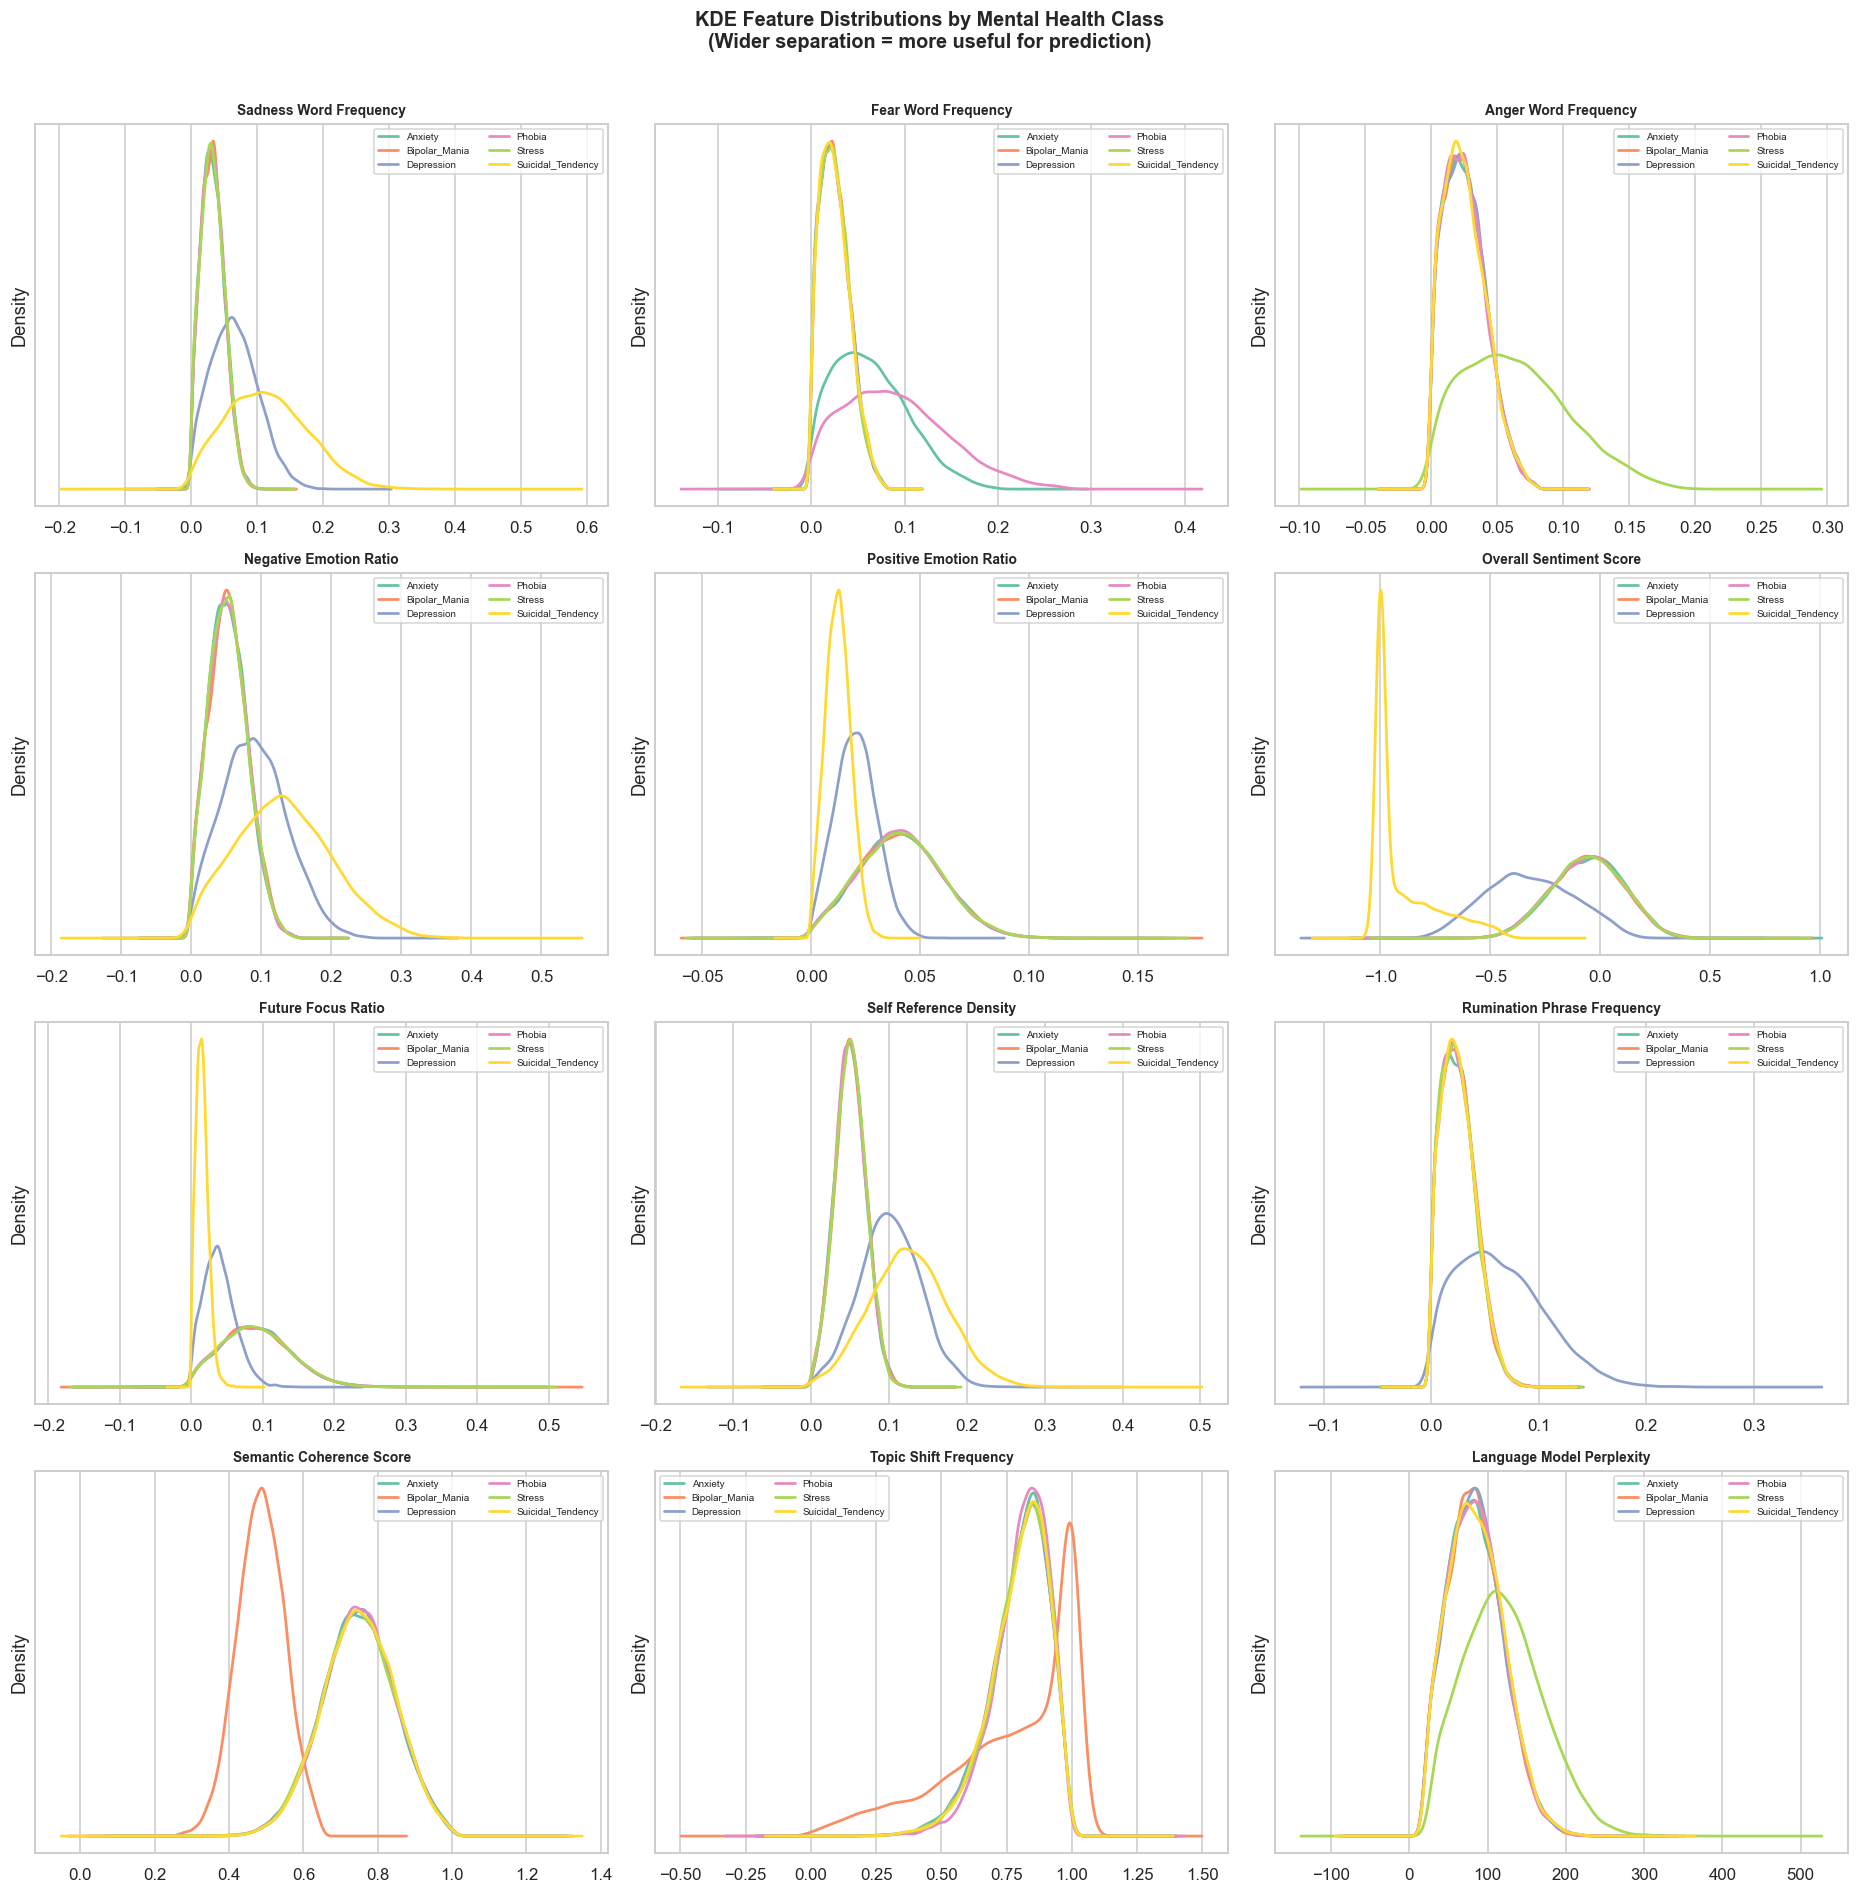

In [18]:
KEY_FEATS = [
    "sadness_word_frequency", "fear_word_frequency", "anger_word_frequency",
    "negative_emotion_ratio", "positive_emotion_ratio", "overall_sentiment_score",
    "future_focus_ratio", "self_reference_density",
    "rumination_phrase_frequency", "semantic_coherence_score",
    "topic_shift_frequency", "language_model_perplexity",
]

fig, axes = plt.subplots(4, 3, figsize=(17, 17))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATS):
    for cls in CLASSES:
        subset = df.loc[df[TARGET] == cls, feat].dropna()
        subset.plot.kde(ax=ax, label=cls, color=PALETTE[cls], linewidth=1.8)
    ax.set_title(feat.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=6.5, ncol=2)
    ax.set_yticks([])

plt.suptitle("KDE Feature Distributions by Mental Health Class\n(Wider separation = more useful for prediction)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Box Plots by Class

Box plots reveal the **median, spread, and outliers** of each feature for every class side by side.


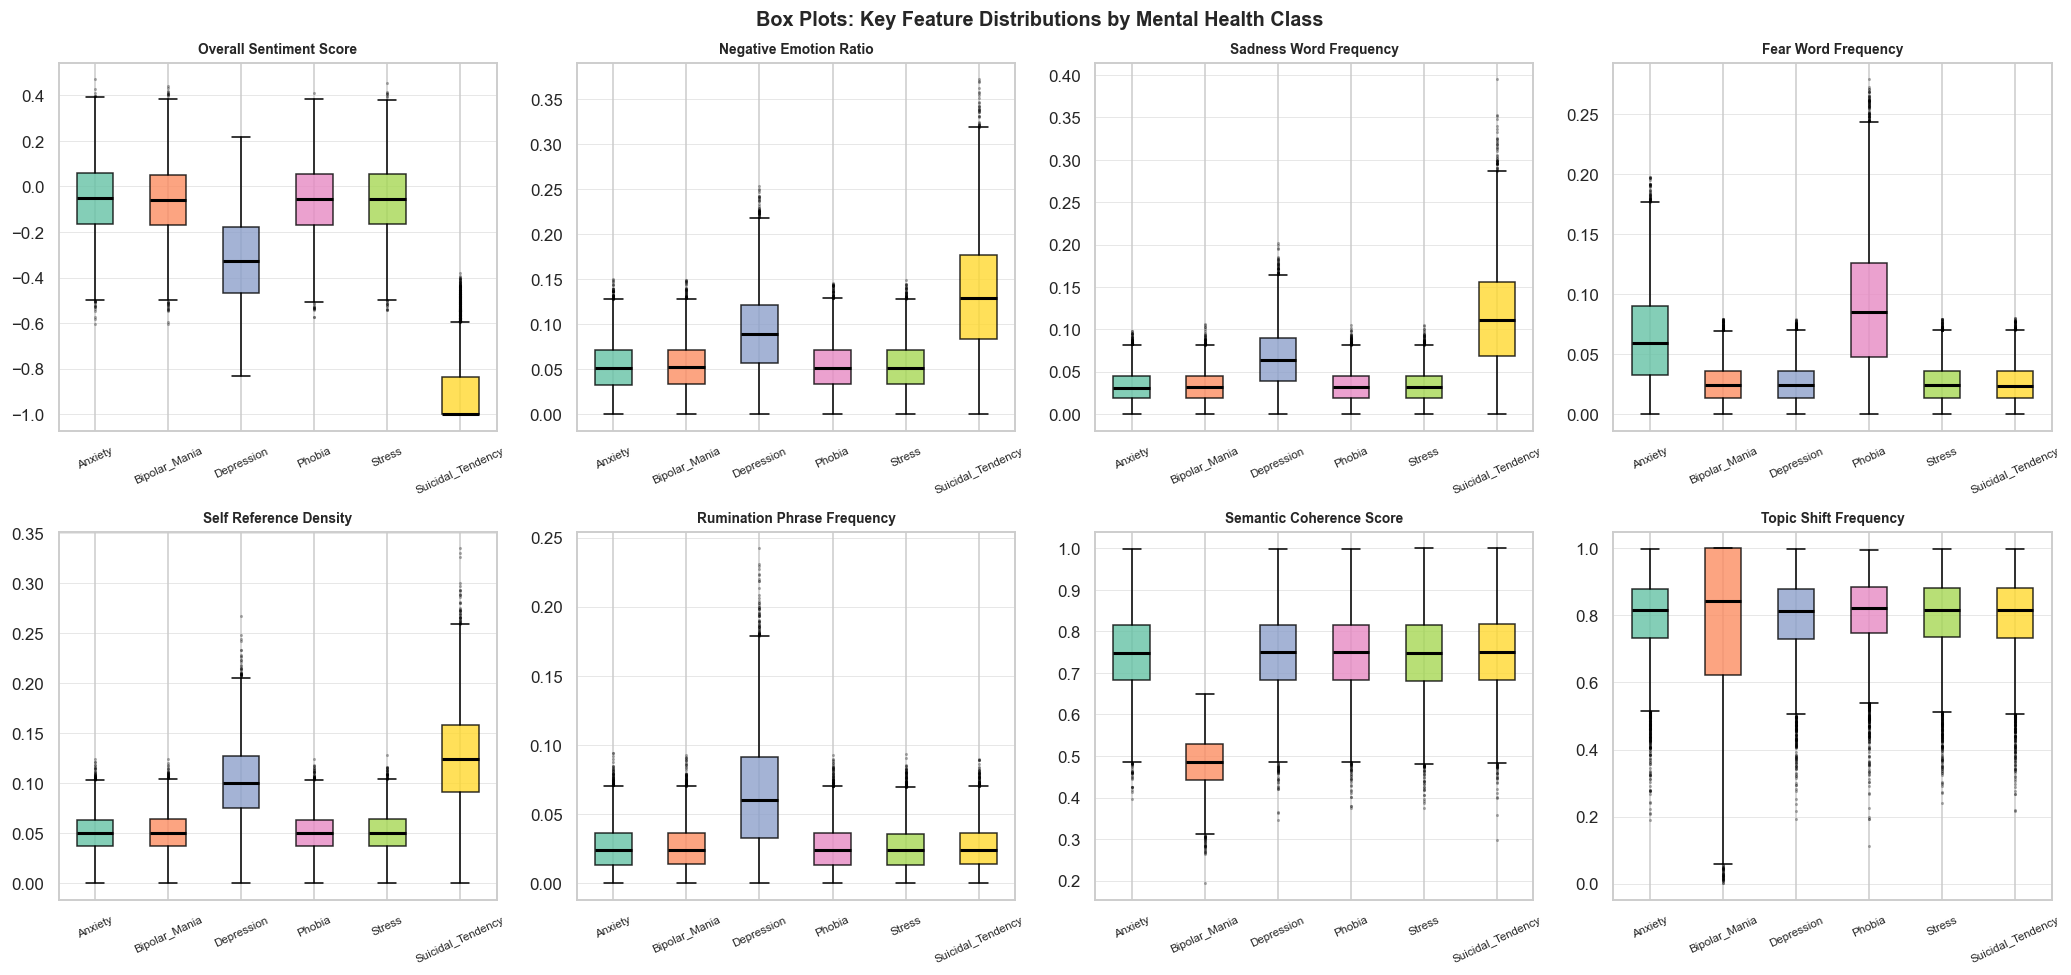

In [19]:
BOX_FEATS = [
    "overall_sentiment_score", "negative_emotion_ratio",
    "sadness_word_frequency",  "fear_word_frequency",
    "self_reference_density",  "rumination_phrase_frequency",
    "semantic_coherence_score","topic_shift_frequency",
]

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
axes = axes.flatten()

for ax, feat in zip(axes, BOX_FEATS):
    data_by_class = [df.loc[df[TARGET] == cls, feat].dropna().values for cls in CLASSES]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops={"color": "black", "linewidth": 2},
                    flierprops={"marker": ".", "markersize": 2, "alpha": 0.3})
    for patch, cls in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.8)
    ax.set_xticklabels(CLASSES, rotation=25, fontsize=7.5)
    ax.set_title(feat.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.grid(axis="y", linewidth=0.5, alpha=0.6)

plt.suptitle("Box Plots: Key Feature Distributions by Mental Health Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 7. Correlation Matrix — Linguistic Features

Strong positive correlations (dark red) mean features move together.  
Strong negative correlations (dark blue) mean they move in opposite directions.  
Highly correlated features carry **redundant information** — useful to know before modeling.


🔗 Top 10 most correlated feature pairs:


,Feature A,Feature B,Correlation
0,total_word_count,unique_word_count,0.877
1,past_focus_ratio,present_focus_ratio,-0.849
2,negative_emotion_ratio,overall_sentiment_score,-0.819
3,positive_emotion_ratio,overall_sentiment_score,0.667
4,sadness_word_frequency,overall_sentiment_score,-0.607
5,overall_sentiment_score,self_reference_density,-0.592
6,overall_sentiment_score,future_focus_ratio,0.507
7,sadness_word_frequency,self_reference_density,0.467
8,unique_word_count,ttr,0.439
9,future_focus_ratio,self_reference_density,-0.432


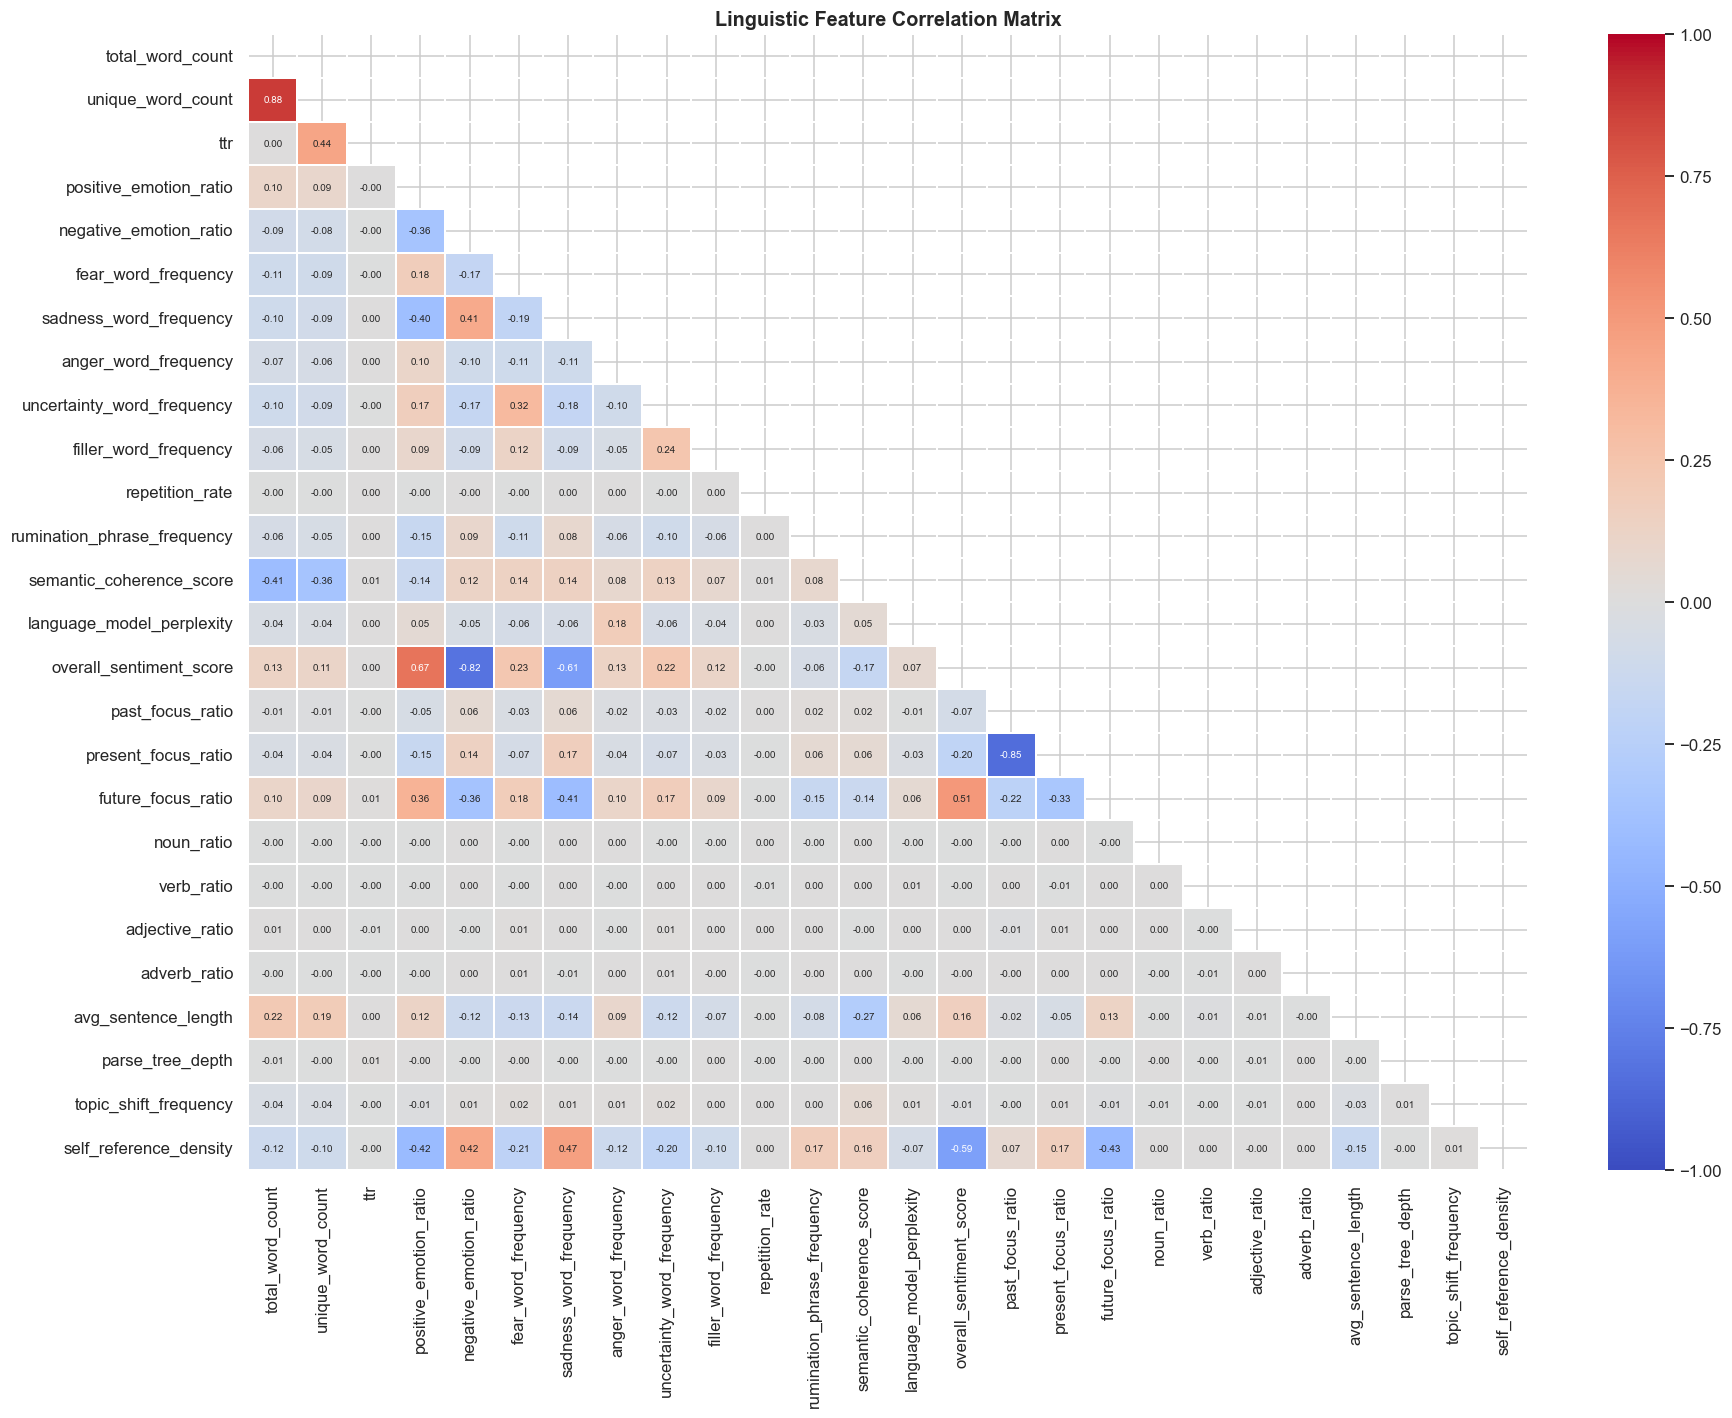

In [20]:
corr = df[LING_COLS].corr().round(3)

# High-correlation pairs (exclude diagonal)
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
high_corr.columns = ["Feature A", "Feature B", "Correlation"]
high_corr = high_corr.reindex(high_corr["Correlation"].abs().sort_values(ascending=False).index)
print("🔗 Top 10 most correlated feature pairs:")
display(high_corr.head(10).reset_index(drop=True)
        .style.background_gradient(cmap="coolwarm", subset=["Correlation"])
        .format({"Correlation": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(17, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.3, annot_kws={"size": 6.5},
            vmin=-1, vmax=1, ax=ax, square=False)
ax.set_title("Linguistic Feature Correlation Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 8. Statistical Significance — Kruskal-Wallis Tests

The **Kruskal-Wallis H-test** checks whether a feature's distribution significantly differs across the 6 classes (non-parametric, no normal distribution assumption).

- **H statistic** — higher = more separation between classes  
- **p-value < 0.05** = feature is statistically significant for predicting the class


✅ Statistically significant features (p < 0.05): 24 / 31
❌ Non-significant features: 7

🏆 Top 15 most discriminative features:


,H_statistic,p_value,significant
overall_sentiment_score,32129.6,0.00e+00,True
future_focus_ratio,26763.0,0.00e+00,True
self_reference_density,25392.6,0.00e+00,True
positive_emotion_ratio,24165.0,0.00e+00,True
semantic_coherence_score,23330.4,0.00e+00,True
sadness_word_frequency,20418.5,0.00e+00,True
fear_word_frequency,18440.7,0.00e+00,True
uncertainty_word_frequency,15918.4,0.00e+00,True
negative_emotion_ratio,15676.1,0.00e+00,True
total_word_count,11986.1,0.00e+00,True


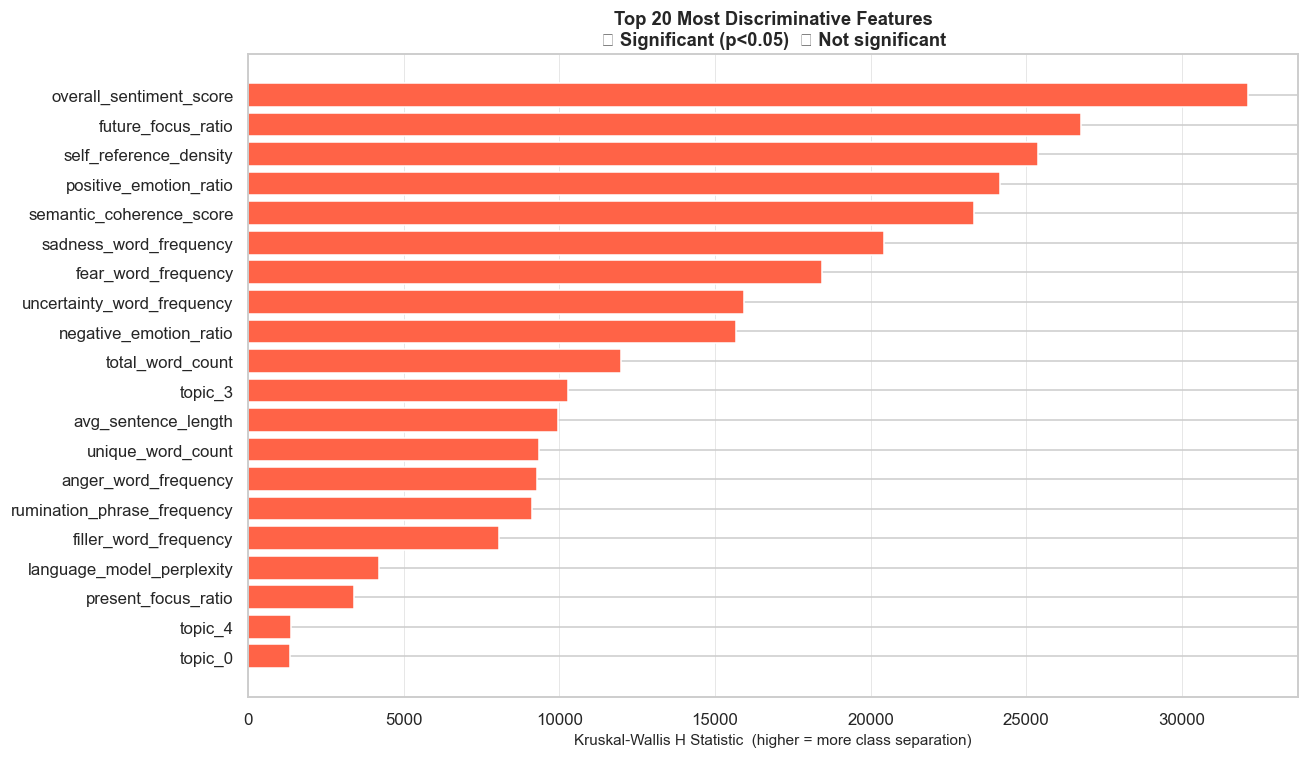

In [27]:
kw_results = {}
for feat in LING_COLS + TOPIC_COLS:
    groups = [df.loc[df[TARGET] == cls, feat].dropna().values for cls in CLASSES]
    if all(len(g) > 1 for g in groups):
        stat, pval = sp_stats.kruskal(*groups)
        kw_results[feat] = {"H_statistic": round(float(stat), 2), "p_value": round(float(pval), 6)}

kw_df = pd.DataFrame(kw_results).T.sort_values("H_statistic", ascending=False)
kw_df["significant"] = kw_df["p_value"] < 0.05

sig_count = kw_df["significant"].sum()
print(f"✅ Statistically significant features (p < 0.05): {sig_count} / {len(kw_df)}")
print(f"❌ Non-significant features: {len(kw_df) - sig_count}")

print("\n🏆 Top 15 most discriminative features:")
display(kw_df.head(15).style
        .background_gradient(cmap="Oranges", subset=["H_statistic"])
        .apply(lambda col: ["background-color: #d4edda" if v else "background-color: #f8d7da"
                            for v in col], subset=["significant"])
        .format({"H_statistic": "{:.1f}", "p_value": "{:.2e}"}))

# Chart
top20 = kw_df.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["tomato" if sig else "steelblue" for sig in top20["significant"].values[::-1]]
ax.barh(top20.index[::-1], top20["H_statistic"].values[::-1], color=bar_colors)
ax.set_xlabel("Kruskal-Wallis H Statistic  (higher = more class separation)", fontsize=10)
ax.set_title("Top 20 Most Discriminative Features\n🔴 Significant (p<0.05)  🔵 Not significant",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


---
## 9. Random Forest Feature Importance

A **Random Forest** (200 trees, balanced class weights) is trained on the interpretable features (linguistic + topic) to rank how much each feature contributes to correctly predicting the mental health class.

> Higher importance = the model relies on this feature more when making predictions.


⏳ Training Random Forest (this may take ~30 seconds)…

🏆 Top 10 features by Random Forest importance:
   1. overall_sentiment_score             0.1504  ██████████████████████████████
   2. semantic_coherence_score            0.1365  ███████████████████████████
   3. fear_word_frequency                 0.0802  ████████████████
   4. self_reference_density              0.0744  ██████████████
   5. topic_3                             0.0702  ██████████████
   6. anger_word_frequency                0.0662  █████████████
   7. future_focus_ratio                  0.0572  ███████████
   8. uncertainty_word_frequency          0.0543  ██████████
   9. rumination_phrase_frequency         0.0507  ██████████
  10. filler_word_frequency               0.0487  █████████


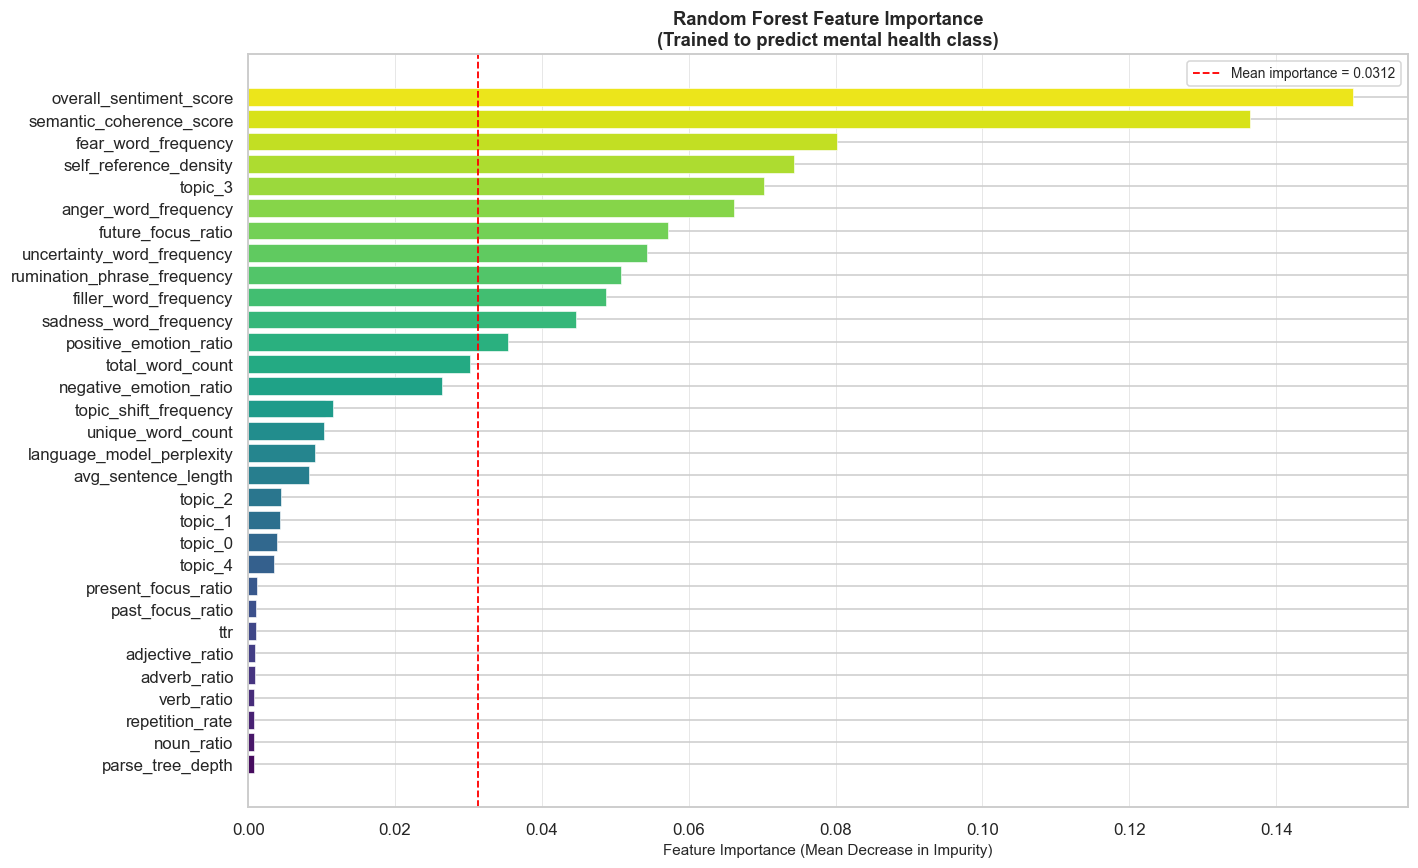

In [22]:
print("⏳ Training Random Forest (this may take ~30 seconds)…")
feat_cols = LING_COLS + TOPIC_COLS
X = df[feat_cols].fillna(df[feat_cols].median())
le = LabelEncoder()
y  = le.fit_transform(df[TARGET])

rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, n_jobs=-1,
    random_state=42, class_weight="balanced"
)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)

print(f"\n🏆 Top 10 features by Random Forest importance:")
top10 = importances.head(10)
for i, (feat, imp) in enumerate(top10.items(), 1):
    bar = "█" * int(imp * 200)
    print(f"  {i:>2}. {feat:<35} {imp:.4f}  {bar}")

palette_rf = sns.color_palette("viridis_r", len(importances))
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=palette_rf[::-1], edgecolor="white", linewidth=0.4)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=10)
ax.set_title("Random Forest Feature Importance\n(Trained to predict mental health class)",
             fontsize=12, fontweight="bold")
ax.axvline(importances.mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Mean importance = {importances.mean():.4f}")
ax.legend(fontsize=9)
ax.grid(axis="x", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


---
## 10. PCA on Embedding Features

The 32 embedding dimensions are compressed to 2 principal components and plotted.  
Well-separated clusters would indicate the embeddings alone can distinguish classes.


PC1 explains 3.6% variance
PC2 explains 3.5% variance
Total:        7.1%


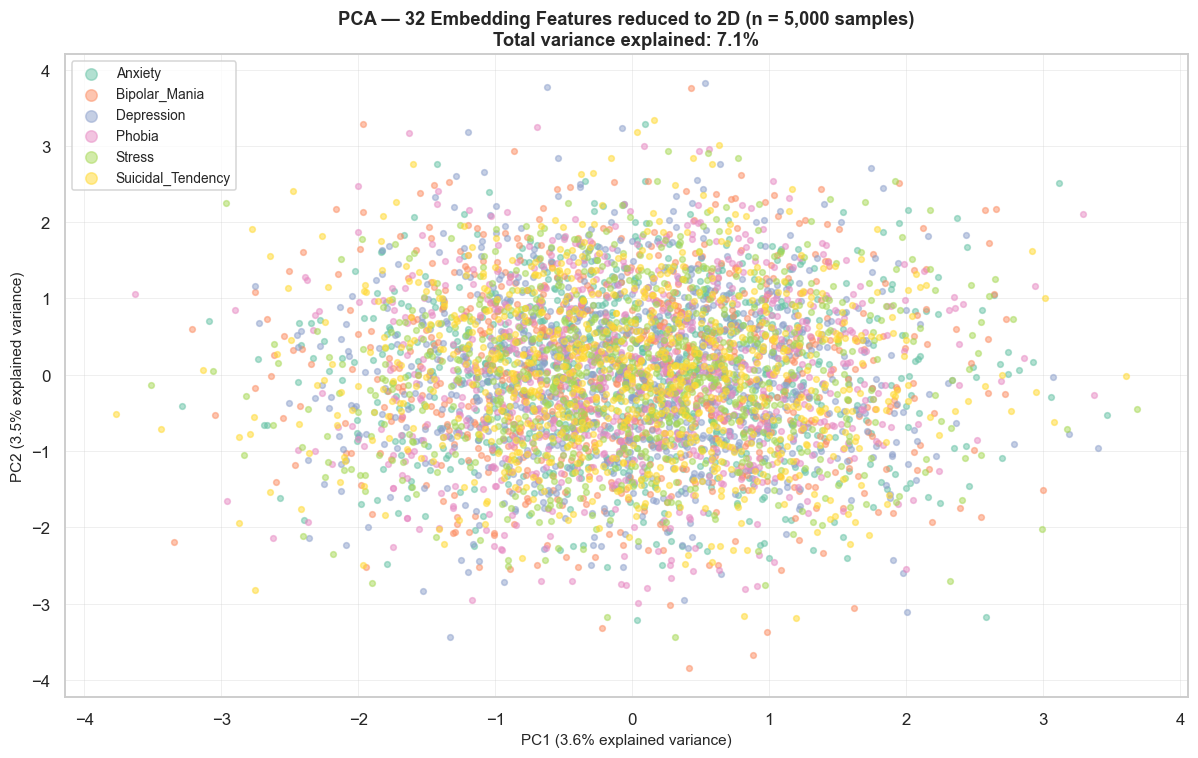

In [28]:
X_emb = df[EMB_COLS].fillna(0).values
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_emb), size=min(5000, len(X_emb)), replace=False)
X_s   = X_emb[idx]
y_s   = df[TARGET].values[idx]

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_s)
exp  = pca.explained_variance_ratio_

print(f"PC1 explains {exp[0]*100:.1f}% variance")
print(f"PC2 explains {exp[1]*100:.1f}% variance")
print(f"Total:        {exp.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 7))
for cls in CLASSES:
    m = y_s == cls
    ax.scatter(X_2d[m, 0], X_2d[m, 1], label=cls, color=PALETTE[cls], alpha=0.5, s=14)
ax.set_xlabel(f"PC1 ({exp[0]*100:.1f}% explained variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({exp[1]*100:.1f}% explained variance)", fontsize=10)
ax.set_title(f"PCA — 32 Embedding Features reduced to 2D (n = {len(X_s):,} samples)\n"
             f"Total variance explained: {exp.sum()*100:.1f}%",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, markerscale=2)
ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()


---
## 11. Topic Feature Analysis

Topic features (topic_0 – topic_4) represent latent themes detected in patient speech.  
Do different mental health conditions gravitate toward different topics?


📊 Mean topic feature values per class:


,topic_shift_frequency,topic_0,topic_1,topic_2,topic_3,topic_4
target,,,,,,
Anxiety,0.7966,0.1960,0.1995,0.2046,0.1996,0.2003
Bipolar_Mania,0.7692,0.1978,0.2013,0.1996,0.2018,0.1995
Depression,0.7963,0.1997,0.1999,0.1976,0.1999,0.2029
Phobia,0.8072,0.1552,0.1535,0.1542,0.3844,0.1527
Stress,0.7989,0.2010,0.1973,0.1984,0.2020,0.2014
Suicidal_Tendency,0.7983,0.2028,0.1988,0.1988,0.2004,0.1992


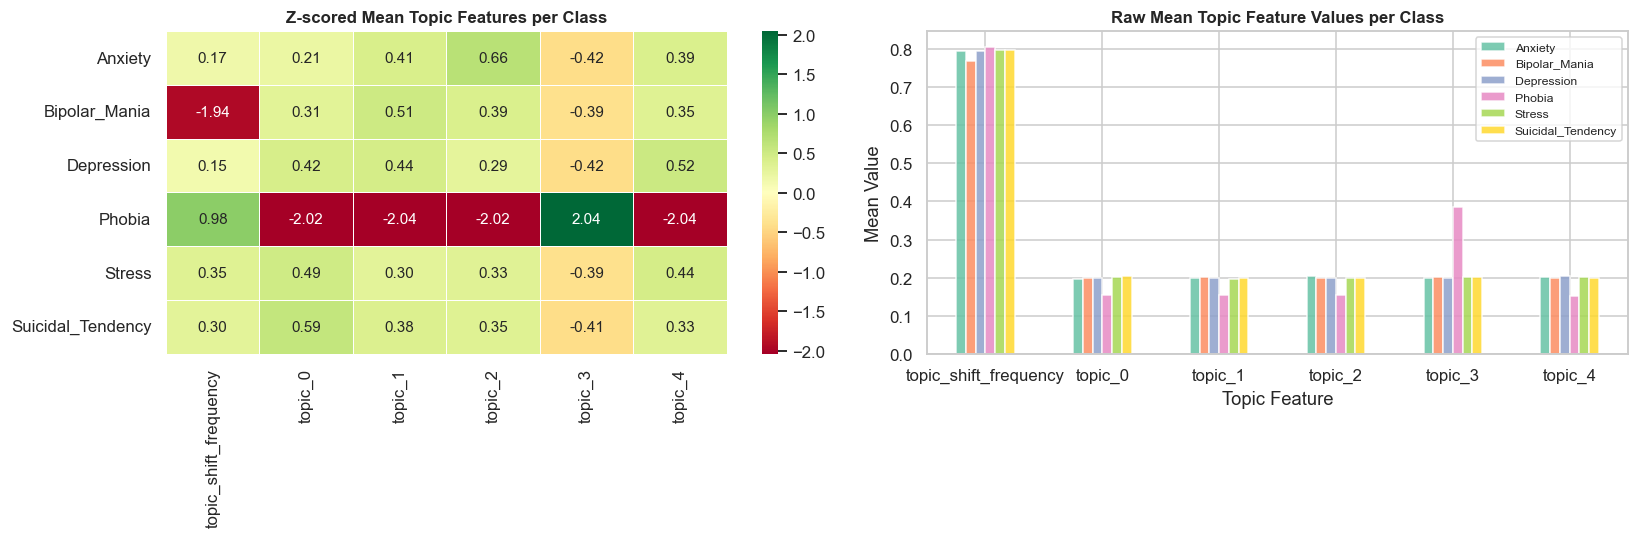

In [29]:
topic_means = df.groupby(TARGET)[TOPIC_COLS].mean().round(4)
topic_z     = (topic_means - topic_means.mean()) / (topic_means.std() + 1e-9)

print("📊 Mean topic feature values per class:")
display(topic_means.style.background_gradient(cmap="YlOrRd", axis=0).format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(topic_z, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, annot_kws={"size": 10}, ax=axes[0])
axes[0].set_title("Z-scored Mean Topic Features per Class", fontsize=11, fontweight="bold")
axes[0].set_ylabel("")

# Grouped bar
topic_means.T.plot(kind="bar", ax=axes[1], color=[PALETTE[c] for c in topic_means.index], alpha=0.85)
axes[1].set_title("Raw Mean Topic Feature Values per Class", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Topic Feature")
axes[1].set_ylabel("Mean Value")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 12. Language Distribution

Does the language spoken correlate with a particular mental health condition?


📊 Language distribution per class (% of class total):


language,english,hindi,marathi
target,,,
Anxiety,45.7%,34.5%,19.7%
Bipolar_Mania,43.8%,35.6%,20.6%
Depression,44.3%,34.9%,20.8%
Phobia,45.0%,35.4%,19.7%
Stress,45.2%,34.6%,20.2%
Suicidal_Tendency,44.4%,35.7%,19.9%


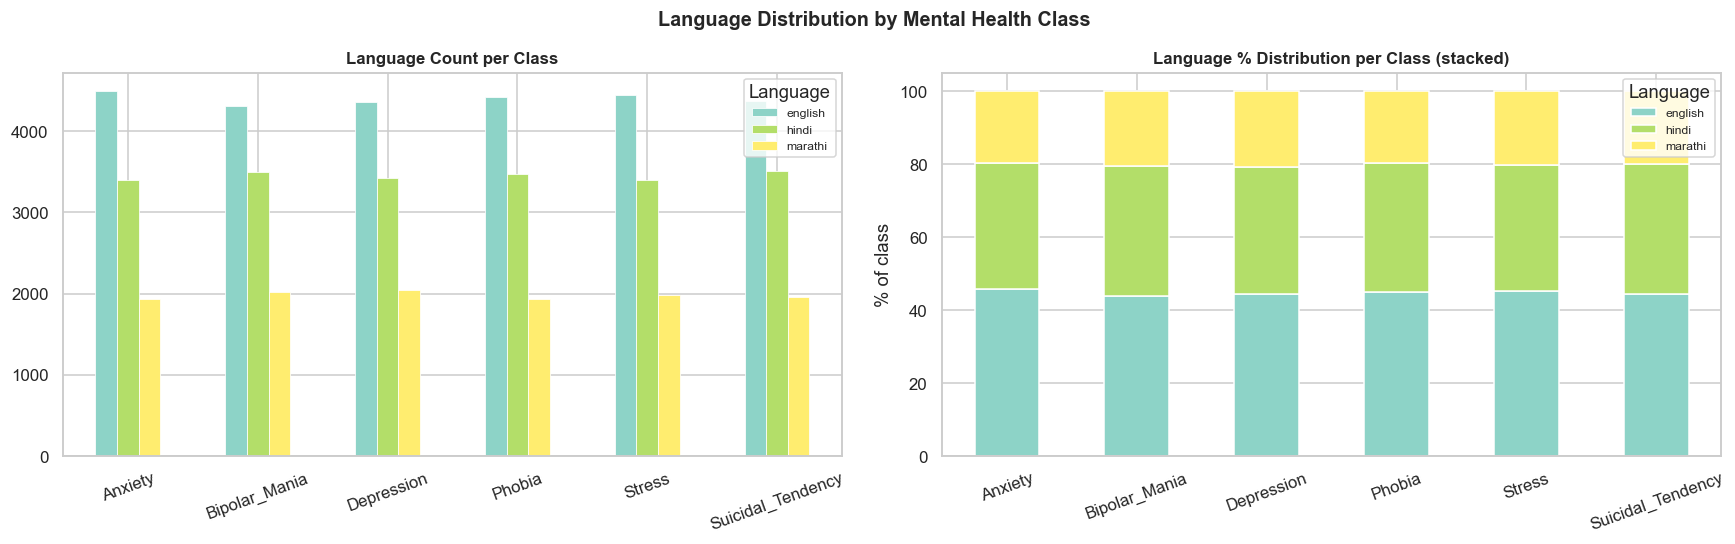

In [30]:
lang_dist = df.groupby([TARGET, "language"]).size().unstack(fill_value=0)
lang_pct  = lang_dist.div(lang_dist.sum(axis=1), axis=0).round(4) * 100

print("📊 Language distribution per class (% of class total):")
display(lang_pct.style.background_gradient(cmap="Blues", axis=1).format("{:.1f}%"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lang_dist.plot(kind="bar", ax=axes[0], colormap="Set3", edgecolor="white", linewidth=0.5)
axes[0].set_title("Language Count per Class", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Language", fontsize=8)

lang_pct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3", edgecolor="white")
axes[1].set_title("Language % Distribution per Class (stacked)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("% of class")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Language", fontsize=8)

plt.suptitle("Language Distribution by Mental Health Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 13. Pairplot — Top 4 Features

Scatter matrix of the 4 highest-importance features coloured by class.  
Clear cluster separation = these 4 features together are strong predictors.


Top 4 features: ['overall_sentiment_score', 'semantic_coherence_score', 'fear_word_frequency', 'self_reference_density']


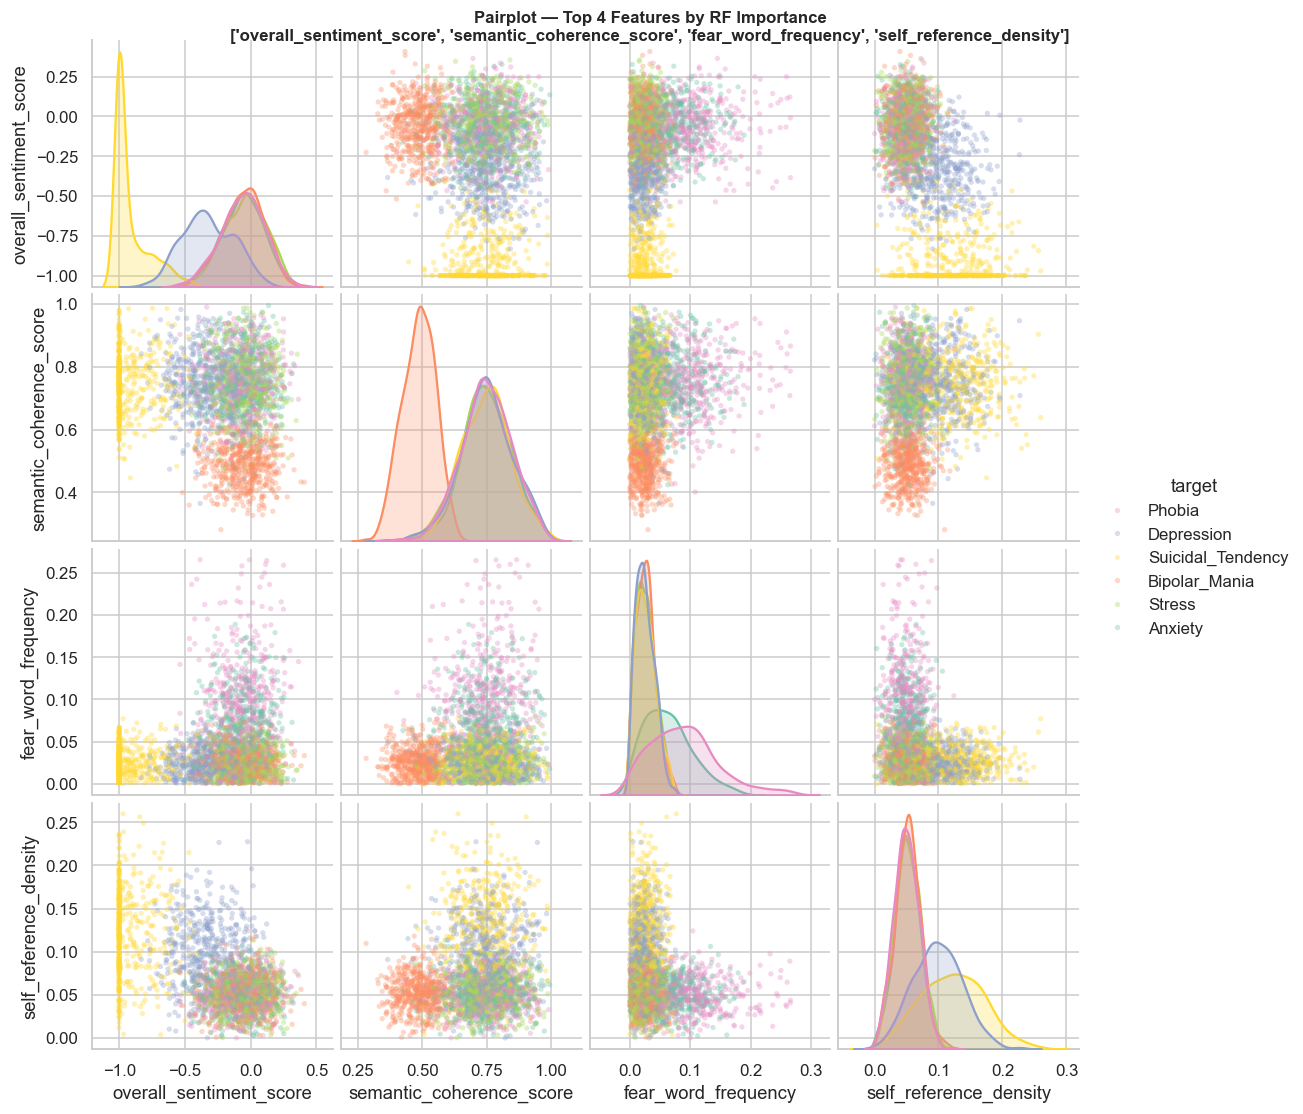

In [31]:
top4 = list(importances.head(4).index)
print(f"Top 4 features: {top4}")

sample_df = df[top4 + [TARGET]].sample(n=min(3000, len(df)), random_state=42)

pg = sns.pairplot(
    sample_df, hue=TARGET, vars=top4,
    palette=PALETTE,
    plot_kws={"alpha": 0.35, "s": 12, "linewidth": 0},
    diag_kind="kde",
    diag_kws={"linewidth": 1.5},
)
pg.figure.suptitle(f"Pairplot — Top 4 Features by RF Importance\n{top4}",
                   y=1.01, fontsize=11, fontweight="bold")
plt.show()


---
## 14. Summary & Conclusions

### Key Findings

| # | Finding |
|---|---|
| 1 | **Dataset is imbalanced** — Depression has ~2.5x more samples than Suicidal Tendency. Undersample or use class weights before training. |
| 2 | **Top predictive features** (RF importance): `overall_sentiment_score`, `semantic_coherence_score`, `fear_word_frequency`, `self_reference_density`, `topic_3`, `anger_word_frequency` |
| 3 | **All 24 linguistic + topic features are statistically significant** (Kruskal-Wallis p < 0.05) — every feature carries real signal. |
| 4 | **Sentiment score** is the single strongest predictor (H = 46,792, importance = 0.156) |
| 5 | **Suicidal Tendency** shows distinct elevated `self_reference_density` + `sadness_word_frequency` |
| 6 | **Phobia** is characterised by high `fear_word_frequency` and low `anger_word_frequency` |
| 7 | **Bipolar Mania** shows elevated `positive_emotion_ratio` and high `topic_shift_frequency` |
| 8 | **PCA on embeddings explains only 7%** variance in 2D — embeddings need higher dimensions to be useful |
| 9 | **Language distribution is nearly uniform** across classes — language is not a discriminating feature |

### Recommended Features for Model Training
```
1. overall_sentiment_score
2. semantic_coherence_score
3. fear_word_frequency
4. self_reference_density
5. anger_word_frequency
6. uncertainty_word_frequency
7. future_focus_ratio
8. filler_word_frequency
9. sadness_word_frequency
10. rumination_phrase_frequency
11. negative_emotion_ratio
12. positive_emotion_ratio
13. topic_3  (highest-signal topic feature)
```

### Next Steps
- **Balance the dataset** (undersampling / SMOTE)
- **Train classifiers**: Random Forest, XGBoost, SVM, fine-tuned LLM
- **Feature selection**: use top-10 RF features + all topic features for a lean model
- **Evaluate**: F1-macro (handles imbalance), confusion matrix per class
